# Sentiment Analysis

Load processed comments with preprocessed text variants from the preprocessing notebook.

In [114]:
import json
from pathlib import Path
from collections import Counter
import nltk
import matplotlib.pyplot as plt
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from transformers import AutoModelForSequenceClassification, AutoTokenizer

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_processed.json"
SENTIMENT_PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_sentiment_processed.json"


In [115]:

with open(PROCESSED_VIDEO_DATA_PATH, "r", encoding="utf-8") as f:
    processed_video_data = json.load(f)

processed_comments = processed_video_data["comments"]
print(f"Loaded {len(processed_comments)} processed comments\n")

Loaded 46834 processed comments



In [ ]:
SENTIMENT_TEXT_FIELD = "comment_text_sentiment_analysis"
TOTAL_EXAMPLES = 10

def print_sentiment_examples(rows, sentiment_field, label, analysis_name, total_examples=TOTAL_EXAMPLES, text_field=SENTIMENT_TEXT_FIELD):
    examples = []
    for row in rows:
        if row.get(sentiment_field) == label:
            examples.append(row)
    upper_label = label.upper()
    
    print(f"\n{analysis_name} {upper_label} SENTIMENT EXAMPLES")
    print(80 * "=")
    for example in examples[:total_examples]:
        print("-", example.get(text_field, ""))

def print_sentiment_distribution(counter, total_comments, heading):
    print(heading)
    print(80 * "=")
    print(f"Analysed comments: {total_comments}")
    for label, count in counter.most_common():
        pct = 100 * count / total_comments if total_comments else 0
        print(f"{label}: {count:,} ({pct:.2f}%)")


SENTIMENT ANALYSIS TEXT EXAMPLES

ID: Ugx4TmtthtmdHtePwqV4AaABAg
Original: The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..
For VADER: The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..

ID: Ugylw87AQ2Q4CkseUkt4AaABAg
Original: Free the CHILDREN
For VADER: Free the CHILDREN

ID: UgxGdNOPXiLmPW4AD4R4AaABAg
Original: Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
For VADER: Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤

ID: Ugz8mOUwbqV8xANIC-F4AaABAg
Original: Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
For VADER: Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤

ID: UgyQpepxkSysJf72hn94AaABAg
Original: Why that song?
For VADER: Why that song?

ID: UgwuNhzfeMcNr7V5liF4AaABAg
Original: When the Queen, Beyoncé showed up, the crowd went crazy! ❤❤❤❤❤❤❤❤❤❤
For VADER: When the Queen, B

In [ ]:

print("SENTIMENT ANALYSIS TEXT EXAMPLES")
print("=" * 80)
processed_data = processed_comments
for comment in processed_comments[:TOTAL_EXAMPLES]:
    print(f"\nID: {comment.get('comment_id')}")
    print(f"Original: {comment.get('comment_text')}")
    print(f"For VADER: {comment.get(SENTIMENT_TEXT_FIELD)}")


In [117]:
VADER_POSITIVE_THRESHOLD = 0.05
VADER_NEGATIVE_THRESHOLD = -0.05

VADER_SENTIMENT_FIELDS = [
    "vader_compound",
    "vader_sentiment",
]

BERT_SENTIMENT_FIELDS = [
    "bert_sentiment",
    "bert_sentiment_raw",
    "bert_confidence",
    "bert_negative",
    "bert_neutral",
    "bert_positive",
]

TOPIC_ANALYSIS_FIELDS = [
    "comment_text_topic",
    "comment_tokens_topic",
    "comment_text_topic_stemmed",
    "comment_tokens_topic_stemmed",
    "topic_token_count",
]

NETWORK_ANALYSIS_FIELDS = [
    "comment_id",
    "comment_author_id",
    "comment_author",
    "video_id",
    "channel_id",
    "comment_published_at",
    "comment_like_count",
    "is_reply",
    "parent_comment_id",
    "reply_to_author_id",
    "celebs",
    "brands",
]

REQUIRED_OUTPUT_FIELDS = []
REQUIRED_OUTPUT_FIELDS.extend(TOPIC_ANALYSIS_FIELDS)
REQUIRED_OUTPUT_FIELDS.extend(NETWORK_ANALYSIS_FIELDS)
REQUIRED_OUTPUT_FIELDS.extend(VADER_SENTIMENT_FIELDS)
REQUIRED_OUTPUT_FIELDS.extend(BERT_SENTIMENT_FIELDS)

In [ ]:
def rows_have_fields(rows, fields):
    for row in rows:
        for field in fields:
            if field not in row:
                return False
    return True

has_vader_sentiment = rows_have_fields(processed_data, VADER_SENTIMENT_FIELDS)
has_bert_sentiment = rows_have_fields(processed_data, BERT_SENTIMENT_FIELDS)


In [119]:
def label_vader_sentiment(compound_score):
    if compound_score >= VADER_POSITIVE_THRESHOLD:
        return "positive"
    if compound_score <= VADER_NEGATIVE_THRESHOLD:
        return "negative"
    return "neutral"

def vader_sentiment_analysis(processed_data):
    """
    Use VADER lexicon for sentiment analysis on processed YouTube comment data.

    @param processed_data: list of dicts with comment text and published date keys
    @returns: list of VADER sentiment result dicts, aligned to processed_data order
    """
    sent_analyser = SentimentIntensityAnalyzer()
    sentiment_results = []

    for entry in processed_data:
        vader_text = entry[SENTIMENT_TEXT_FIELD]
        post_date = entry.get("comment_published_at", None)
        scores = sent_analyser.polarity_scores(vader_text)
        compound_score = scores["compound"]

        sentiment_results.append({
            "comment_id": entry.get("comment_id"),
            "published_at": post_date,
            "vader_compound": compound_score,
            "vader_sentiment": label_vader_sentiment(compound_score),
        })
    return sentiment_results


In [120]:
if not has_vader_sentiment:
    for row, result in zip(processed_data, vader_sentiment_analysis(processed_data)):
        row["vader_compound"] = result["vader_compound"]
        row["vader_sentiment"] = result["vader_sentiment"]


In [121]:
vader_sentiment = []
for row in processed_data:
    result = {
        "comment_id": row["comment_id"],
        "published_at": row.get("comment_published_at"),
        "vader_compound": row["vader_compound"],
        "vader_sentiment": row["vader_sentiment"],
    }
    vader_sentiment.append(result)

vader_compound_scores = []
for result in vader_sentiment:
    vader_compound_scores.append(result["vader_compound"])

vader_series = pd.Series(vader_compound_scores)


In [122]:

vader_sentiment_counter = Counter()
for row in processed_data:
    vader_sentiment_counter[row["vader_sentiment"]] += 1
print_sentiment_distribution(vader_sentiment_counter, len(processed_data), "VADER SENTIMENT SUMMARY")


VADER SENTIMENT SUMMARY
Analysed comments: 46834
positive: 21,753 (46.45%)
neutral: 14,307 (30.55%)
negative: 10,774 (23.00%)


In [123]:
print_sentiment_examples(processed_data, "vader_sentiment", "positive", "VADER")
print_sentiment_examples(processed_data, "vader_sentiment", "negative", "VADER")
print_sentiment_examples(processed_data, "vader_sentiment", "neutral", "VADER")



VADER POSITIVE SENTIMENT EXAMPLES
- Free the CHILDREN
- Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
- Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
- Kardashians looking great, Mom, the head of the family wearing a fabulous Kimono, it's amazing. ❤❤❤
- Everyone looks outstanding, so much creative art and unique designs. I love Cher black outfit with her leather and bright shiny materials. Cher stands out always. ❤❤❤
- West African Doechi representing "dark female energy" is superb. I love her unique outfit.❤❤❤
- Some beautiful fabrics, but I'm afraid I cannot understand anyone, and certainly not wealthy or famous women who believe that turning around to be admired while trying to appear nude or even being partly nude, is showing self-respect. Dressing well is important, but exposing too much is tacky, regardless of how expensive or fabulous the dress is. Having the steps when so many can barely walk up them always seems pretty counterintuitive.
- I love fashion..
- Beyonce 

In [124]:
SENTIMENT_ORDER = ["negative", "neutral", "positive"]
SENTIMENT_COLORS = {
    "positive": "#32cd32",    # lime
    "neutral": "#bdbdbd",     # light grey
    "negative": "#ff6347",    # tomato
}
SENTIMENT_FREE_COLOR = "magenta"

## 1. Sentiment Distribution

Baseline count of positive, neutral, and negative VADER labels.

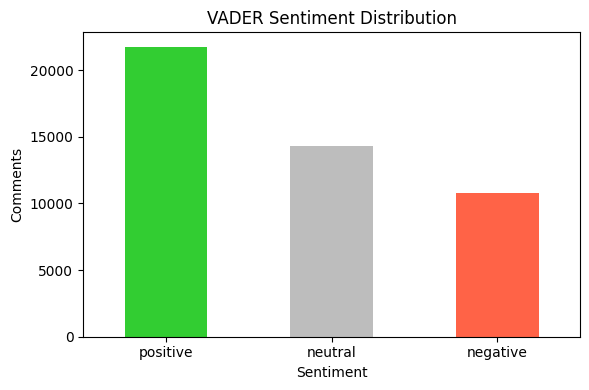

In [125]:
# Sentiment dataframe
sentiment_df = pd.DataFrame(processed_data).copy()

# Convert comment_published_at to datetime with error handling
sentiment_df["comment_published_at"] = pd.to_datetime(sentiment_df["comment_published_at"], errors="coerce")

# Count how many comments fall into each VADER sentiment category
sentiment_counts = sentiment_df["vader_sentiment"].value_counts()

sentiment_bar_colors = []
for label in sentiment_counts.index:
    sentiment_bar_colors.append(SENTIMENT_COLORS[label])

fig, ax = plt.subplots(figsize=(6, 4))
ax = sentiment_counts.plot(
    kind="bar",
    ax=ax,
    color=sentiment_bar_colors,
    rot=0,
    title="VADER Sentiment Distribution",
)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Comments")
plt.tight_layout()


## 2. Sentiment Over Time

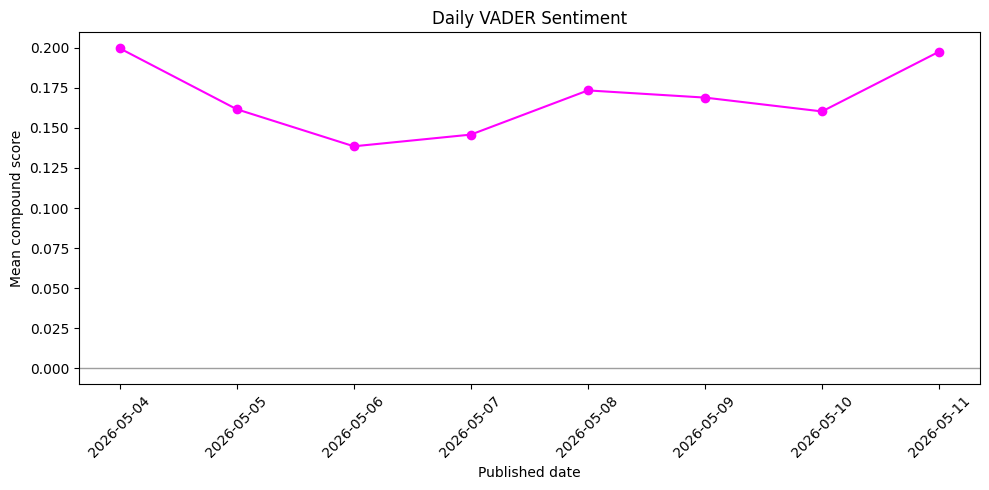

In [126]:
vader_sentiment_df = pd.DataFrame(vader_sentiment).dropna(subset=["published_at"]).copy()
vader_sentiment_df["published_date"] = pd.to_datetime(vader_sentiment_df["published_at"]).dt.date

daily_sentiment = vader_sentiment_df.groupby("published_date")["vader_compound"].mean().reset_index(name="mean_compound")
daily_sentiment["published_date"] = daily_sentiment["published_date"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_sentiment["published_date"], daily_sentiment["mean_compound"], marker="o", color=SENTIMENT_FREE_COLOR)
ax.set_title("Daily VADER Sentiment")
ax.set_xlabel("Published date")
ax.set_ylabel("Mean compound score")
ax.axhline(0, color="#9e9e9e", linewidth=1)
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()


## 3. Sentiment by Entity

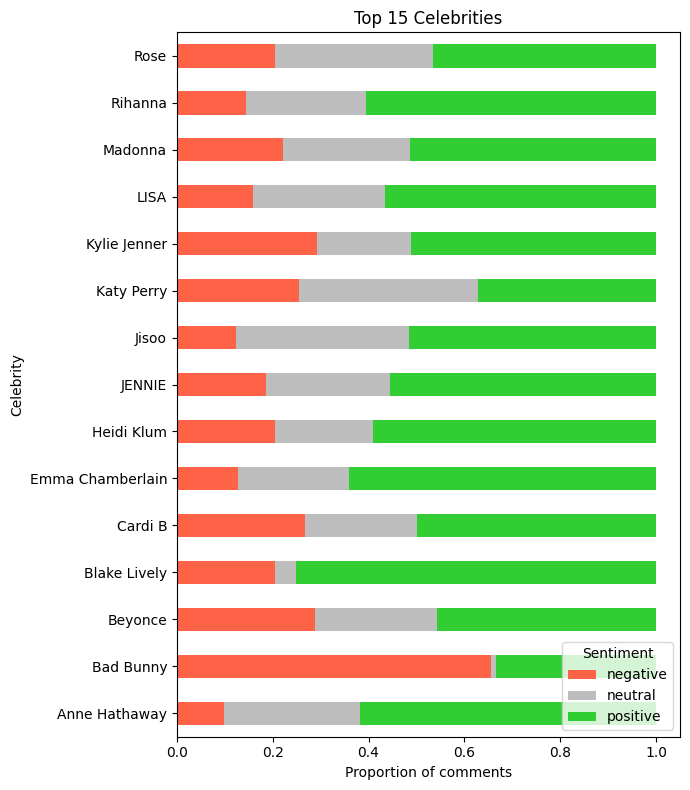

In [127]:

TOP_CELEB_COUNT = 15

celeb_rows = sentiment_df.explode("celebs").dropna(subset=["celebs"])
top_celebs = celeb_rows["celebs"].value_counts().head(TOP_CELEB_COUNT).index
celeb_sentiment = (
    celeb_rows[celeb_rows["celebs"].isin(top_celebs)]
    .groupby(["celebs", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
celeb_sentiment_share = celeb_sentiment.div(celeb_sentiment.sum(axis=1), axis=0).fillna(0)

celeb_sentiment_colors = []
for label in celeb_sentiment_share.columns:
    celeb_sentiment_colors.append(SENTIMENT_COLORS[label])

fig, ax = plt.subplots(figsize=(7, 8))
celeb_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=celeb_sentiment_colors,
    title=f"Top {TOP_CELEB_COUNT} Celebrities",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Celebrity")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()



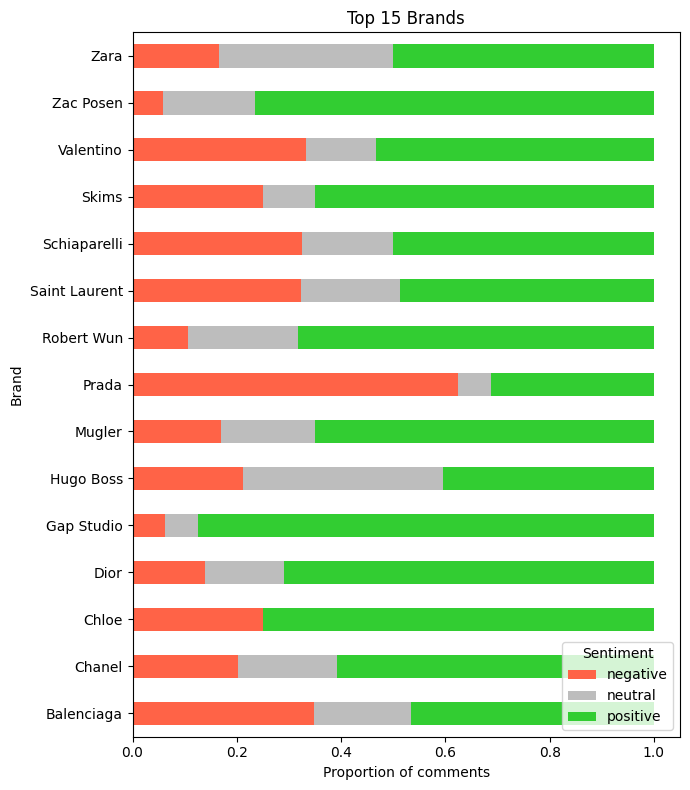

In [128]:

TOP_BRAND_COUNT = 15
brand_rows = sentiment_df.explode("brands").dropna(subset=["brands"])
top_brands = brand_rows["brands"].value_counts().head(TOP_BRAND_COUNT).index
brand_sentiment = (
    brand_rows[brand_rows["brands"].isin(top_brands)]
    .groupby(["brands", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
brand_sentiment_share = brand_sentiment.div(brand_sentiment.sum(axis=1), axis=0).fillna(0)

brand_sentiment_colors = []
for label in brand_sentiment_share.columns:
    brand_sentiment_colors.append(SENTIMENT_COLORS[label])

fig, ax = plt.subplots(figsize=(7, 8))
brand_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=brand_sentiment_colors,
    title=f"Top {TOP_BRAND_COUNT} Brands",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Brand")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()


## 5. Entity Mention Frequency

Most-mentioned celebrities and brands, used as context for interpreting entity sentiment.

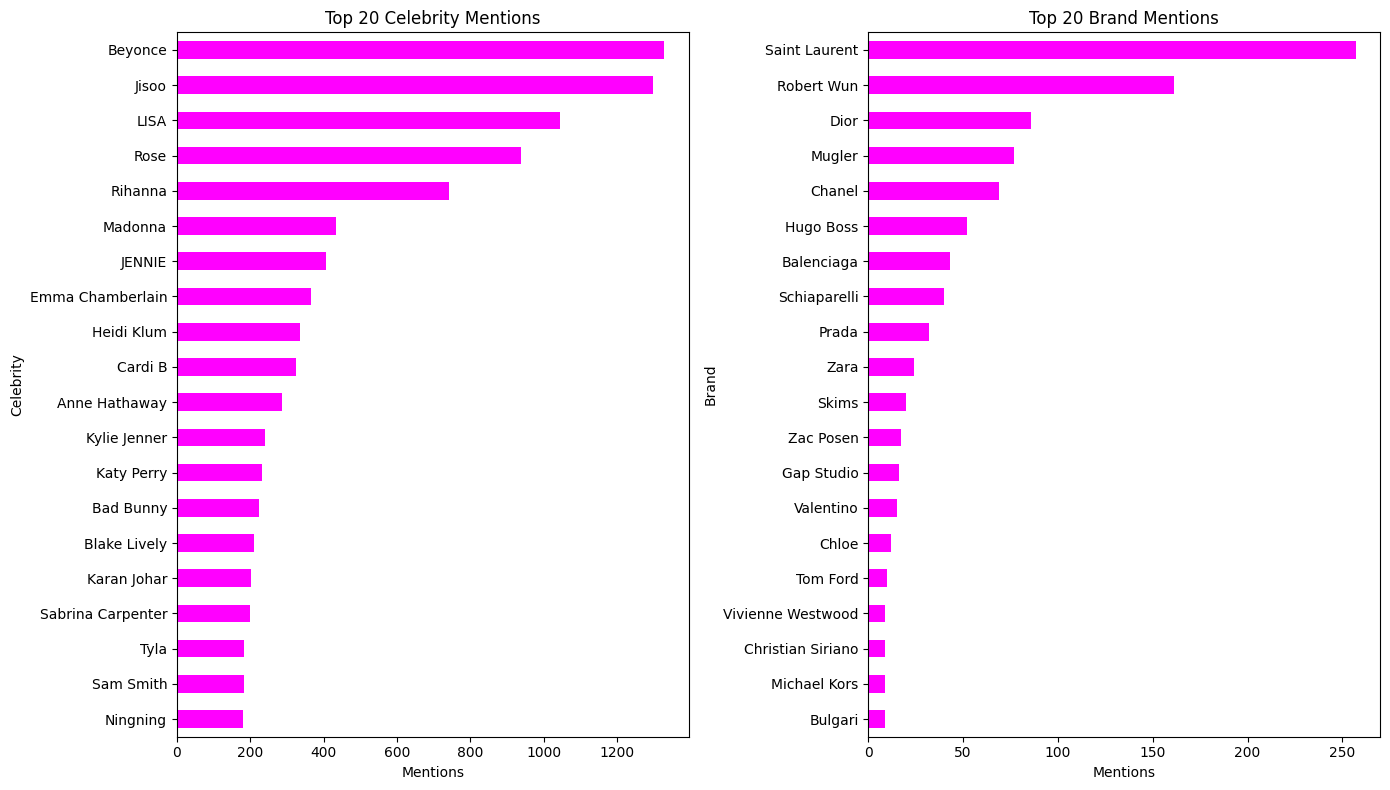

In [129]:
TOP_MENTION_COUNT = 20
celeb_counts = celeb_rows["celebs"].value_counts().head(TOP_MENTION_COUNT).sort_values()
brand_counts = brand_rows["brands"].value_counts().head(TOP_MENTION_COUNT).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
celeb_counts.plot(
    kind="barh",
    ax=axes[0],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Celebrity Mentions",
)
brand_counts.plot(
    kind="barh",
    ax=axes[1],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Brand Mentions",
)
axes[0].set_xlabel("Mentions")
axes[0].set_ylabel("Celebrity")
axes[1].set_xlabel("Mentions")
axes[1].set_ylabel("Brand")
plt.tight_layout()


## BERT-based Sentiment Analysis

In [130]:
BERT_SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
BERT_SENTIMENT_MODEL_NAME = "cardiffnlp-twitter-roberta-base-sentiment-latest"
BERT_SENTIMENT_MODEL_DIR = PROJECT_ROOT / "models" / BERT_SENTIMENT_MODEL_NAME
HF_CACHE_DIR = PROJECT_ROOT / ".cache" / "huggingface"
BERT_CONFIDENCE_THRESHOLD = 0.60
BERT_BATCH_SIZE = 32


In [131]:

# Make model directory and download model if it doesn't exist
if not BERT_SENTIMENT_MODEL_DIR.exists():
    model = AutoModelForSequenceClassification.from_pretrained(BERT_SENTIMENT_MODEL)
    tokenizer = AutoTokenizer.from_pretrained(BERT_SENTIMENT_MODEL)
    BERT_SENTIMENT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(BERT_SENTIMENT_MODEL_DIR)
    tokenizer.save_pretrained(BERT_SENTIMENT_MODEL_DIR)
    print(f"Downloaded and saved model to: {BERT_SENTIMENT_MODEL_DIR}")
else:
    print(f"Loaded model from: {BERT_SENTIMENT_MODEL_DIR}")


Loaded model from: /Users/cooper/Documents/GitHub/Network-Analysis-Project#/models/cardiffnlp-twitter-roberta-base-sentiment-latest


In [132]:
# Initialize the BERT-based sentiment analysis pipeline
sentiment_model = pipeline(
    "text-classification",
    model=str(BERT_SENTIMENT_MODEL_DIR),
    tokenizer=str(BERT_SENTIMENT_MODEL_DIR),
    return_all_scores=True,
    top_k=None,
    truncation=True,
    max_length=512,
    cache_dir=str(HF_CACHE_DIR),
)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25371.83it/s]


In [ ]:
def normalise_bert_label(label):
    """
    Labels defined by the model being used
    Map to readable strings to match VADER labels assigned based on thresholds
    """

    label = label.lower()
    label_map = {
        "label_0": "negative",
        "label_1": "neutral",
        "label_2": "positive",
    }
    return label_map.get(label, label)

# BERT sentiment analysis
def bert_sentiment_analysis(processed_data, threshold=BERT_CONFIDENCE_THRESHOLD):
    texts = []
    for entry in processed_data:
        texts.append(entry.get(SENTIMENT_TEXT_FIELD, ""))

    bert_predictions = sentiment_model(texts, batch_size=BERT_BATCH_SIZE)
    
    results = []
    for entry, scores in zip(processed_data, bert_predictions):

        # Map model labels to readable strings and collect scores
        scores_map = {}
        for score in scores:
            normalised_label = normalise_bert_label(score["label"])
            scores_map[normalised_label] = score["score"]

        # Select the label with the highest score
        top_label = max(scores_map, key=scores_map.get)
        confidence = scores_map[top_label]

        # If the confidence is below the threshold, label as unknown
        label = top_label if confidence >= threshold else "unknown"

        results.append({
            "comment_id": entry.get("comment_id"),
            "bert_sentiment": label,
            "bert_sentiment_raw": top_label,
            "bert_confidence": round(confidence, 4),
            "bert_negative": round(scores_map.get("negative", 0.0), 4),
            "bert_neutral": round(scores_map.get("neutral", 0.0), 4),
            "bert_positive": round(scores_map.get("positive", 0.0), 4),
        })
    return results

In [136]:
if not has_bert_sentiment:
    for row, result in zip(processed_data, bert_sentiment_analysis(processed_data)):
        for field in BERT_SENTIMENT_FIELDS:
            row[field] = result[field]

In [137]:


celeb_counter_for_output = Counter()
brand_counter_for_output = Counter()

for row in processed_data:
    celebs = row.get("celebs", [])
    brands = row.get("brands", [])

    celeb_counter_for_output.update(celebs)
    brand_counter_for_output.update(brands)

sentiment_processed_video_data = processed_video_data.copy()
sentiment_processed_video_data["comments"] = processed_data
sentiment_processed_video_data["entity_counts"] = {
    "celebs": dict(celeb_counter_for_output),
    "brands": dict(brand_counter_for_output),
}

In [138]:

with open(SENTIMENT_PROCESSED_VIDEO_DATA_PATH, "w", encoding="utf-8") as f:
    json.dump(sentiment_processed_video_data, f, ensure_ascii=False, indent=2)

print(f"Saved sentiment processed data to {SENTIMENT_PROCESSED_VIDEO_DATA_PATH}")


Saved sentiment processed data to /Users/cooper/Documents/GitHub/Network-Analysis-Project#/data/video_data_sentiment_processed.json


In [139]:
bert_counter = Counter()
for row in processed_data:
    bert_counter[row["bert_sentiment"]] += 1

print_sentiment_distribution(bert_counter, len(processed_data), "BERT SENTIMENT SUMMARY")


BERT SENTIMENT SUMMARY
Analysed comments: 46834
positive: 14,669 (31.32%)
negative: 14,228 (30.38%)
unknown: 9,027 (19.27%)
neutral: 8,910 (19.02%)


In [140]:
print_sentiment_examples(processed_data, "bert_sentiment", "positive", "BERT")
print_sentiment_examples(processed_data, "bert_sentiment", "negative", "BERT")
print_sentiment_examples(processed_data, "bert_sentiment", "neutral", "BERT")
print_sentiment_examples(processed_data, "bert_sentiment", "unknown", "BERT")



BERT POSITIVE SENTIMENT EXAMPLES
- Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
- Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
- When the Queen, Beyoncé showed up, the crowd went crazy! ❤❤❤❤❤❤❤❤❤❤
- Beyonce art wear is extraordinary.❤❤❤
- Kardashians looking great, Mom, the head of the family wearing a fabulous Kimono, it's amazing. ❤❤❤
- Everyone looks outstanding, so much creative art and unique designs. I love Cher black outfit with her leather and bright shiny materials. Cher stands out always. ❤❤❤
- West African Doechi representing "dark female energy" is superb. I love her unique outfit.❤❤❤
- I love fashion..
- Beyonce gala look is literally her dangerously in love album cover meets 2026 evolution 😉👑
- - Cher (The Queen!)

BERT NEGATIVE SENTIMENT EXAMPLES
- The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..
- We missed figure skater, cause those ladies are just talking and

## BERT Sentiment Distribution

Baseline count of positive, neutral, negative, and unknown BERT labels.

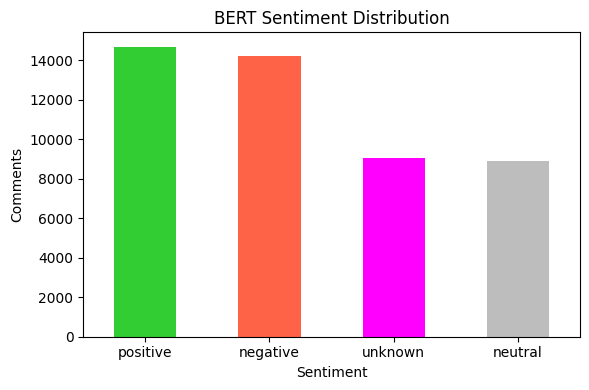

In [141]:
# BERT sentiment dataframe
bert_sentiment_df = pd.DataFrame(processed_data).copy()

# Convert comment_published_at to datetime with error handling
bert_sentiment_df["comment_published_at"] = pd.to_datetime(bert_sentiment_df["comment_published_at"], errors="coerce")

# Count how many comments fall into each BERT sentiment category
bert_sentiment_counts = bert_sentiment_df["bert_sentiment"].value_counts()

bert_sentiment_bar_colors = []
for label in bert_sentiment_counts.index:
    bert_sentiment_bar_colors.append(SENTIMENT_COLORS.get(label, SENTIMENT_FREE_COLOR))

fig, ax = plt.subplots(figsize=(6, 4))
ax = bert_sentiment_counts.plot(
    kind="bar",
    ax=ax,
    color=bert_sentiment_bar_colors,
    rot=0,
    title="BERT Sentiment Distribution",
)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Comments")
plt.tight_layout()


## BERT Sentiment Over Time

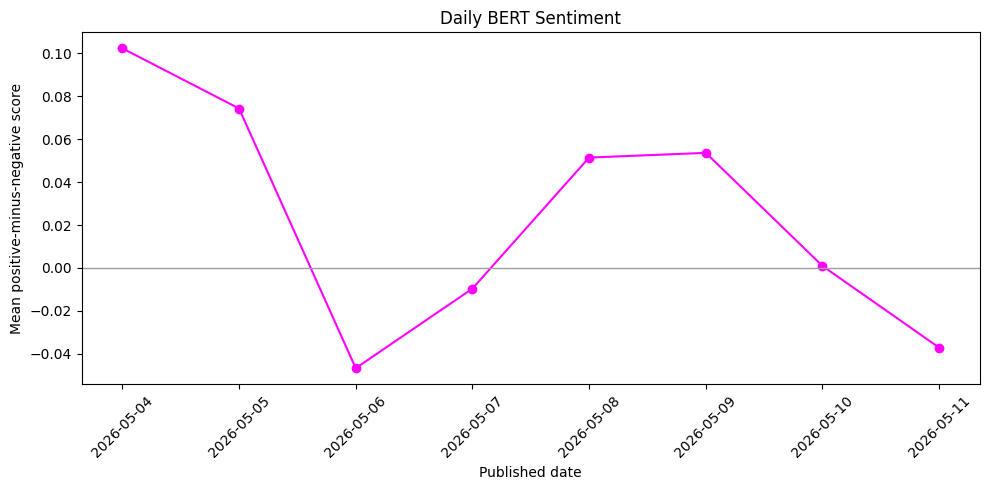

In [142]:
bert_sentiment_over_time_df = bert_sentiment_df.dropna(subset=["comment_published_at"]).copy()
bert_sentiment_over_time_df["published_date"] = bert_sentiment_over_time_df["comment_published_at"].dt.date
bert_sentiment_over_time_df["bert_sentiment_score"] = bert_sentiment_over_time_df["bert_positive"] - bert_sentiment_over_time_df["bert_negative"]

daily_bert_sentiment = bert_sentiment_over_time_df.groupby("published_date")["bert_sentiment_score"].mean().reset_index(name="mean_sentiment")
daily_bert_sentiment["published_date"] = daily_bert_sentiment["published_date"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_bert_sentiment["published_date"], daily_bert_sentiment["mean_sentiment"], marker="o", color=SENTIMENT_FREE_COLOR)
ax.set_title("Daily BERT Sentiment")
ax.set_xlabel("Published date")
ax.set_ylabel("Mean positive-minus-negative score")
ax.axhline(0, color="#9e9e9e", linewidth=1)
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()


## BERT Sentiment by Entity

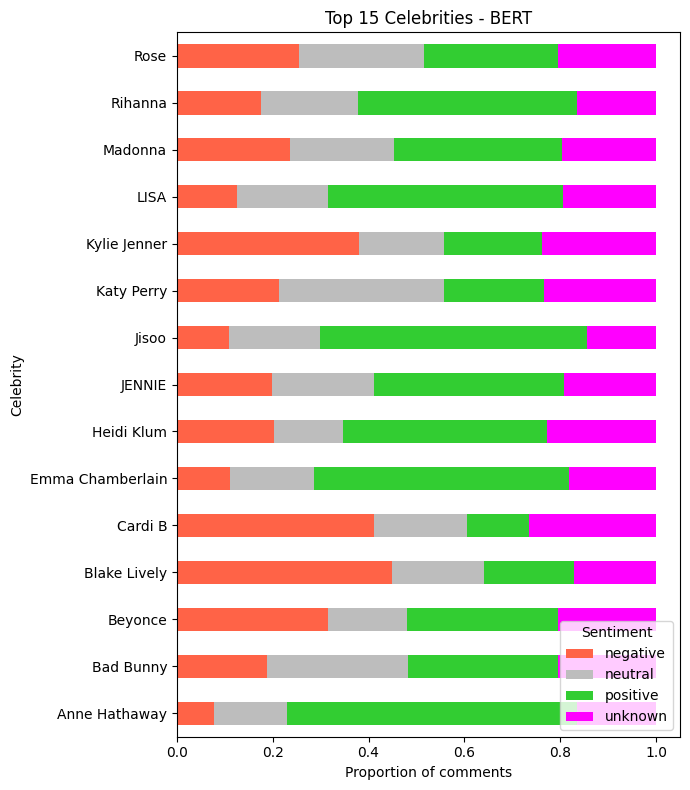

In [143]:
bert_celeb_rows = bert_sentiment_df.explode("celebs").dropna(subset=["celebs"])
bert_top_celebs = bert_celeb_rows["celebs"].value_counts().head(TOP_CELEB_COUNT).index
bert_celeb_sentiment = (
    bert_celeb_rows[bert_celeb_rows["celebs"].isin(bert_top_celebs)]
    .groupby(["celebs", "bert_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER + ["unknown"], fill_value=0)
)
bert_celeb_sentiment_share = bert_celeb_sentiment.div(bert_celeb_sentiment.sum(axis=1), axis=0).fillna(0)

bert_celeb_sentiment_colors = []
for label in bert_celeb_sentiment_share.columns:
    bert_celeb_sentiment_colors.append(SENTIMENT_COLORS.get(label, SENTIMENT_FREE_COLOR))

fig, ax = plt.subplots(figsize=(7, 8))
bert_celeb_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=bert_celeb_sentiment_colors,
    title=f"Top {TOP_CELEB_COUNT} Celebrities - BERT",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Celebrity")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()



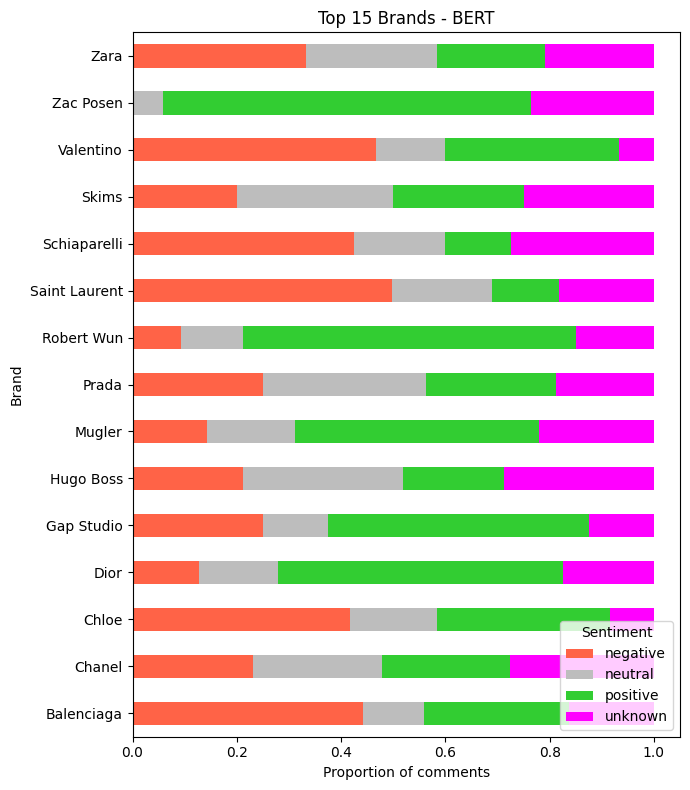

In [144]:
bert_brand_rows = bert_sentiment_df.explode("brands").dropna(subset=["brands"])
bert_top_brands = bert_brand_rows["brands"].value_counts().head(TOP_BRAND_COUNT).index
bert_brand_sentiment = (
    bert_brand_rows[bert_brand_rows["brands"].isin(bert_top_brands)]
    .groupby(["brands", "bert_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER + ["unknown"], fill_value=0)
)
bert_brand_sentiment_share = bert_brand_sentiment.div(bert_brand_sentiment.sum(axis=1), axis=0).fillna(0)

bert_brand_sentiment_colors = []
for label in bert_brand_sentiment_share.columns:
    bert_brand_sentiment_colors.append(SENTIMENT_COLORS.get(label, SENTIMENT_FREE_COLOR))

fig, ax = plt.subplots(figsize=(7, 8))
bert_brand_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=bert_brand_sentiment_colors,
    title=f"Top {TOP_BRAND_COUNT} Brands - BERT",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Brand")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()



## BERT Entity Mention Frequency

Most-mentioned celebrities and brands, used as context for interpreting BERT entity sentiment.

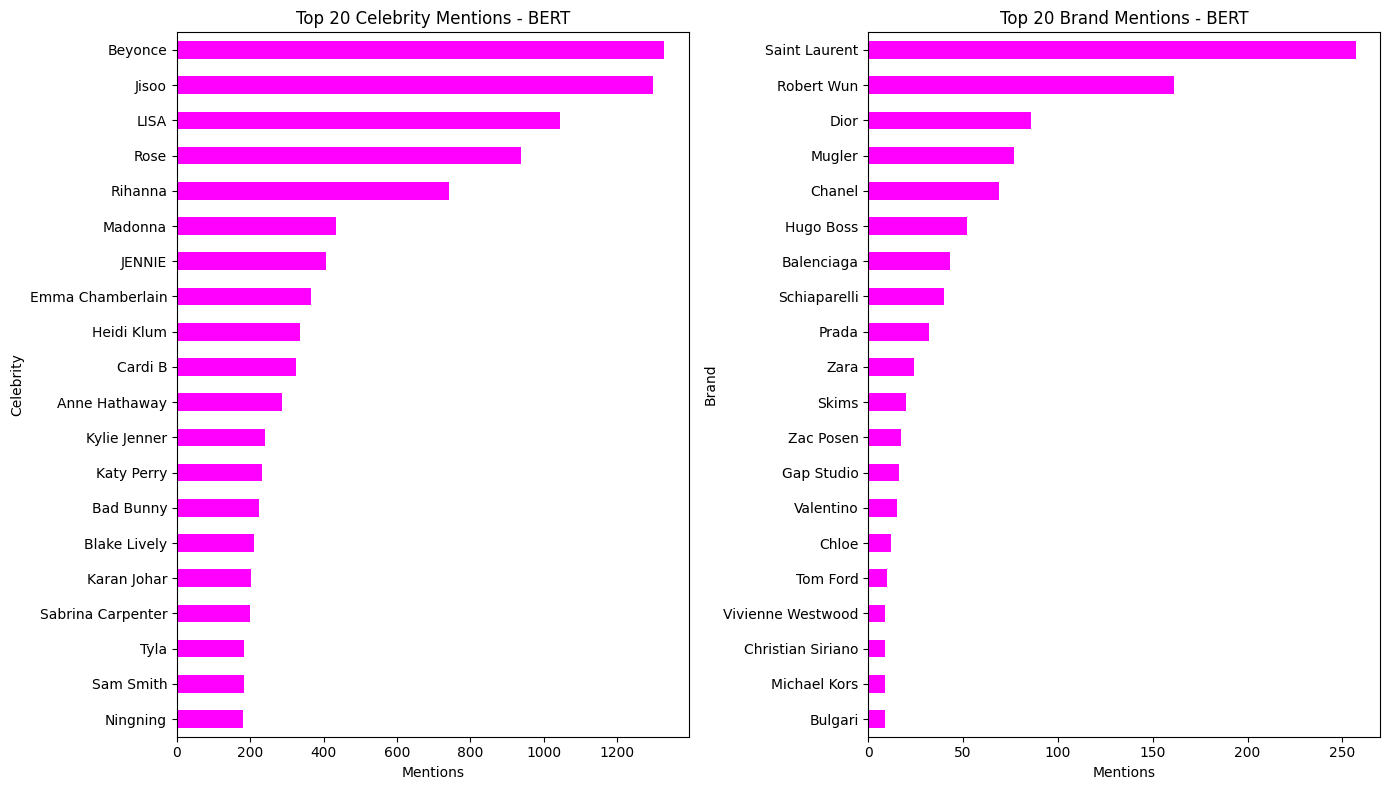

In [145]:
bert_celeb_counts = bert_celeb_rows["celebs"].value_counts().head(TOP_MENTION_COUNT).sort_values()
bert_brand_counts = bert_brand_rows["brands"].value_counts().head(TOP_MENTION_COUNT).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
bert_celeb_counts.plot(
    kind="barh",
    ax=axes[0],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Celebrity Mentions - BERT",
)
bert_brand_counts.plot(
    kind="barh",
    ax=axes[1],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Brand Mentions - BERT",
)
axes[0].set_xlabel("Mentions")
axes[0].set_ylabel("Celebrity")
axes[1].set_xlabel("Mentions")
axes[1].set_ylabel("Brand")
plt.tight_layout()


In [146]:
# Find all rows where matches occurred between methods and return final set of rows
matching_rows = []
for row in processed_data:
    if row["bert_sentiment"] == row["vader_sentiment"]:
        matching_rows.append(row)


In [147]:
matching_counter = Counter()
for row in matching_rows:
    matching_counter[row["bert_sentiment"]] += 1
print_sentiment_distribution(matching_counter, len(matching_rows), "MATCHING SENTIMENT CLASSIFICATIONS")

MATCHING SENTIMENT CLASSIFICATIONS
Analysed comments: 23696
positive: 10,835 (45.73%)
negative: 7,412 (31.28%)
neutral: 5,449 (23.00%)


In [148]:
print_sentiment_examples(matching_rows, "bert_sentiment", "positive", "MATCHING VADER/BERT")
print_sentiment_examples(matching_rows, "bert_sentiment", "negative", "MATCHING VADER/BERT")
print_sentiment_examples(matching_rows, "bert_sentiment", "neutral", "MATCHING VADER/BERT")



MATCHING VADER/BERT POSITIVE SENTIMENT EXAMPLES
- Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
- Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
- Kardashians looking great, Mom, the head of the family wearing a fabulous Kimono, it's amazing. ❤❤❤
- Everyone looks outstanding, so much creative art and unique designs. I love Cher black outfit with her leather and bright shiny materials. Cher stands out always. ❤❤❤
- West African Doechi representing "dark female energy" is superb. I love her unique outfit.❤❤❤
- I love fashion..
- Beyonce gala look is literally her dangerously in love album cover meets 2026 evolution 😉👑
- 🎉❤ And what a beautiful entrance An ice cave sculpture On Discovery Island
- Definitely Panem come to life
- As a person who has done amateur/hobby modeling, I have the utmost respect for all of the models. These costumes are stunning... And I'm sure many of them are uncomfortable. It takes real champions to pull off these pieces 💕 I'm also beyond grateful that 

## Matched Sentiment Distribution

Baseline count of positive, neutral, and negative labels where VADER and BERT agree.

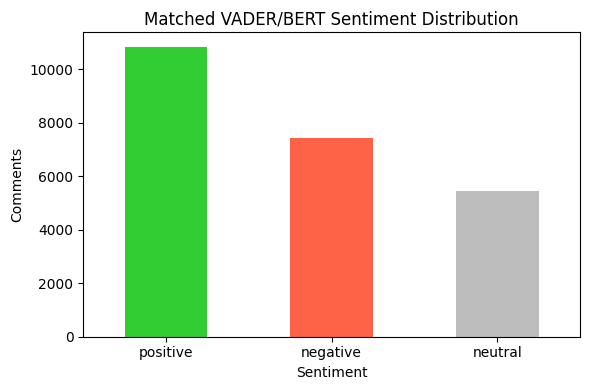

In [149]:
# Matching sentiment dataframe
matching_sentiment_df = pd.DataFrame(matching_rows).copy()

# Convert comment_published_at to datetime with error handling
matching_sentiment_df["comment_published_at"] = pd.to_datetime(matching_sentiment_df["comment_published_at"], errors="coerce")

# Count how many comments fall into each matched sentiment category
matching_sentiment_counts = matching_sentiment_df["bert_sentiment"].value_counts()

matching_sentiment_bar_colors = []
for label in matching_sentiment_counts.index:
    matching_sentiment_bar_colors.append(SENTIMENT_COLORS.get(label, SENTIMENT_FREE_COLOR))

fig, ax = plt.subplots(figsize=(6, 4))
ax = matching_sentiment_counts.plot(
    kind="bar",
    ax=ax,
    color=matching_sentiment_bar_colors,
    rot=0,
    title="Matched VADER/BERT Sentiment Distribution",
)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Comments")
plt.tight_layout()


## Matched Sentiment Over Time

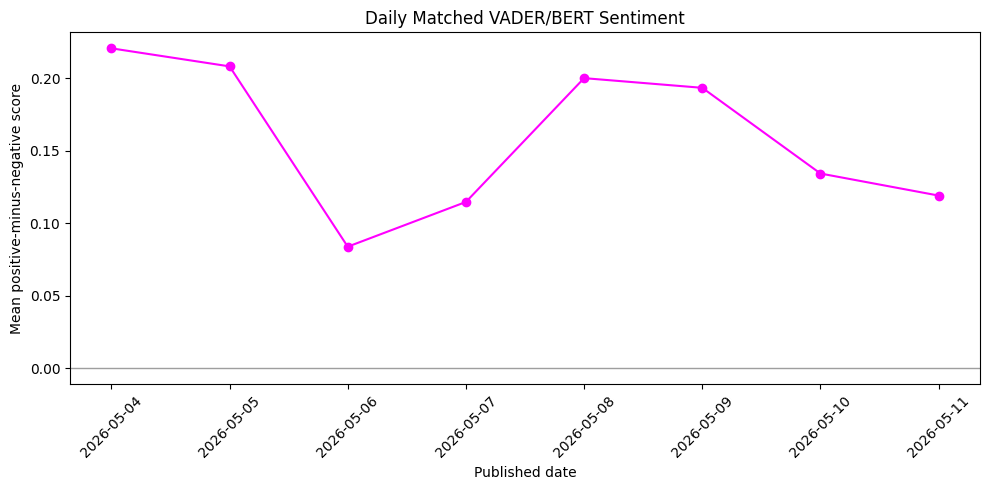

In [150]:
matching_sentiment_over_time_df = matching_sentiment_df.dropna(subset=["comment_published_at"]).copy()
matching_sentiment_over_time_df["published_date"] = matching_sentiment_over_time_df["comment_published_at"].dt.date
matching_sentiment_over_time_df["matching_sentiment_score"] = matching_sentiment_over_time_df["bert_positive"] - matching_sentiment_over_time_df["bert_negative"]

daily_matching_sentiment = matching_sentiment_over_time_df.groupby("published_date")["matching_sentiment_score"].mean().reset_index(name="mean_sentiment")
daily_matching_sentiment["published_date"] = daily_matching_sentiment["published_date"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_matching_sentiment["published_date"], daily_matching_sentiment["mean_sentiment"], marker="o", color=SENTIMENT_FREE_COLOR)
ax.set_title("Daily Matched VADER/BERT Sentiment")
ax.set_xlabel("Published date")
ax.set_ylabel("Mean positive-minus-negative score")
ax.axhline(0, color="#9e9e9e", linewidth=1)
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()


## Matched Sentiment by Entity

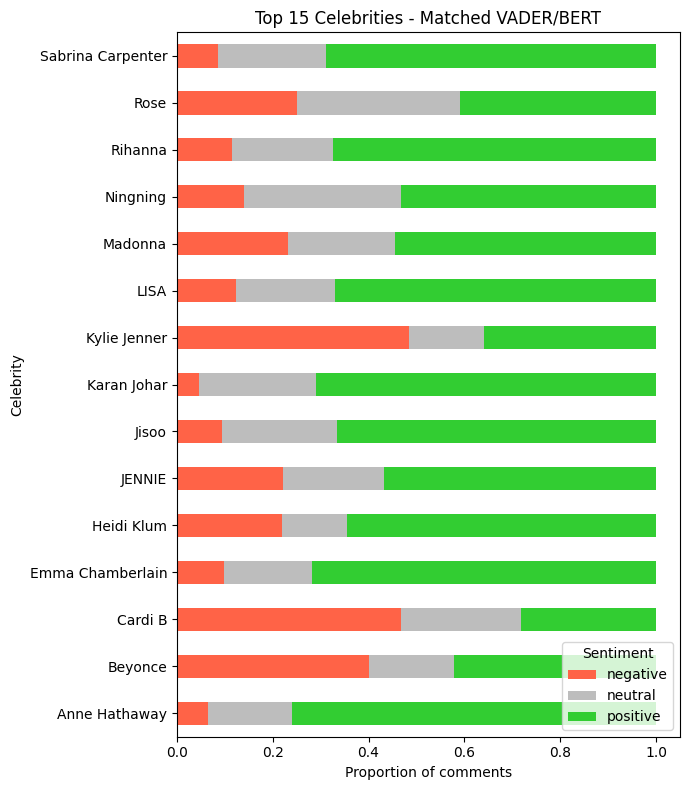

In [151]:
matching_celeb_rows = matching_sentiment_df.explode("celebs").dropna(subset=["celebs"])
matching_top_celebs = matching_celeb_rows["celebs"].value_counts().head(TOP_CELEB_COUNT).index
matching_celeb_sentiment = (
    matching_celeb_rows[matching_celeb_rows["celebs"].isin(matching_top_celebs)]
    .groupby(["celebs", "bert_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
matching_celeb_sentiment_share = matching_celeb_sentiment.div(matching_celeb_sentiment.sum(axis=1), axis=0).fillna(0)

matching_celeb_sentiment_colors = []
for label in matching_celeb_sentiment_share.columns:
    matching_celeb_sentiment_colors.append(SENTIMENT_COLORS[label])

fig, ax = plt.subplots(figsize=(7, 8))
matching_celeb_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=matching_celeb_sentiment_colors,
    title=f"Top {TOP_CELEB_COUNT} Celebrities - Matched VADER/BERT",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Celebrity")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()



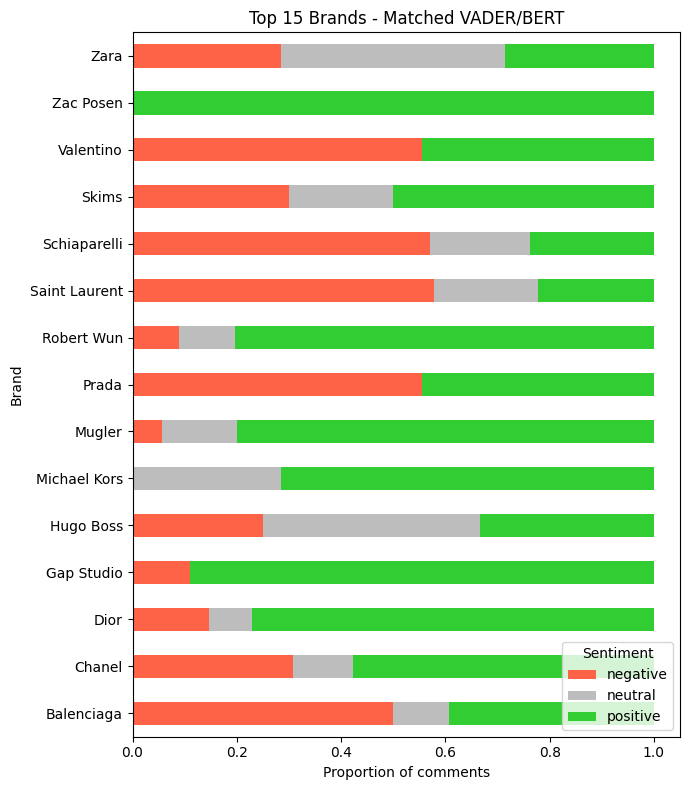

In [152]:
matching_brand_rows = matching_sentiment_df.explode("brands").dropna(subset=["brands"])
matching_top_brands = matching_brand_rows["brands"].value_counts().head(TOP_BRAND_COUNT).index
matching_brand_sentiment = (
    matching_brand_rows[matching_brand_rows["brands"].isin(matching_top_brands)]
    .groupby(["brands", "bert_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
matching_brand_sentiment_share = matching_brand_sentiment.div(matching_brand_sentiment.sum(axis=1), axis=0).fillna(0)

matching_brand_sentiment_colors = []
for label in matching_brand_sentiment_share.columns:
    matching_brand_sentiment_colors.append(SENTIMENT_COLORS[label])

fig, ax = plt.subplots(figsize=(7, 8))
matching_brand_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=matching_brand_sentiment_colors,
    title=f"Top {TOP_BRAND_COUNT} Brands - Matched VADER/BERT",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Brand")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()



## Matched Entity Mention Frequency

Most-mentioned celebrities and brands, used as context for interpreting matched entity sentiment.

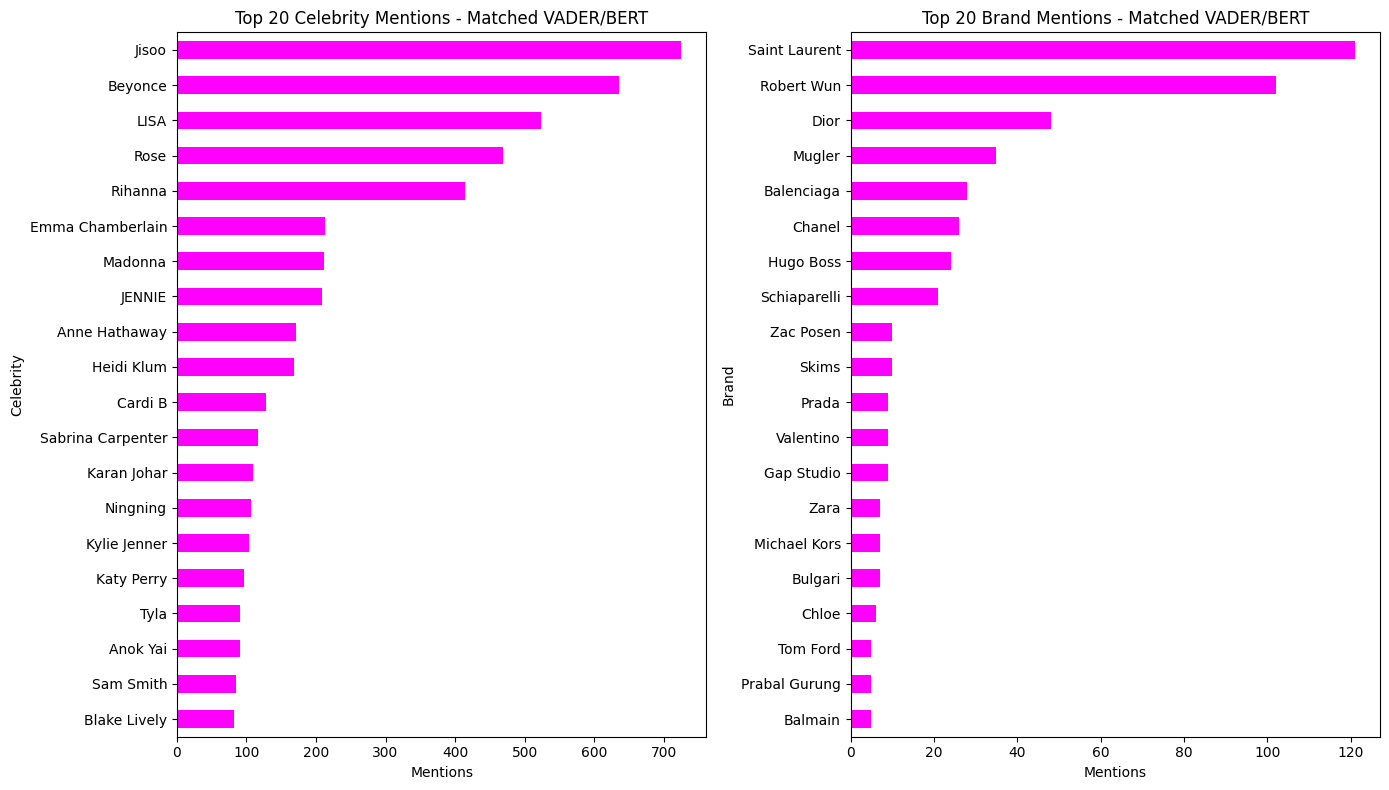

In [153]:
matching_celeb_counts = matching_celeb_rows["celebs"].value_counts().head(TOP_MENTION_COUNT).sort_values()
matching_brand_counts = matching_brand_rows["brands"].value_counts().head(TOP_MENTION_COUNT).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
matching_celeb_counts.plot(
    kind="barh",
    ax=axes[0],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Celebrity Mentions - Matched VADER/BERT",
)
matching_brand_counts.plot(
    kind="barh",
    ax=axes[1],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Brand Mentions - Matched VADER/BERT",
)
axes[0].set_xlabel("Mentions")
axes[0].set_ylabel("Celebrity")
axes[1].set_xlabel("Mentions")
axes[1].set_ylabel("Brand")
plt.tight_layout()
